In [144]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

main_df = pd.read_csv('diabetic_data.csv') 

lookup_df = pd.read_csv('IDs_mapping.csv') 

print("Main Dataset Info:")
print(main_df.info())
print("\nLookup Dataset Head:")
print(lookup_df.head(10))
print("\nLookup Columns:", lookup_df.columns)

Main Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-nul

In [147]:
admission_type_data = []
discharge_data = []
admission_source_data = []

current_section = None

with open('IDs_mapping.csv', 'r') as file:
    for line in file:
        row = line.strip().split(',')
        if len(row) < 2 or row[0] == '':
            continue
        
        if 'admission_type_id' in row[0].lower():
            current_section = 'admission_type'
            continue
        elif 'discharge_disposition_id' in row[0].lower():
            current_section = 'discharge'
            continue
        elif 'admission_source_id' in row[0].lower():
            current_section = 'admission_source'
            continue
        
        if row[0].lower() == 'id' or 'description' in row:
            continue
        
        try:
            if current_section == 'admission_type':
                admission_type_data.append([int(row[0]), row[1]])
            elif current_section == 'discharge':
                discharge_data.append([int(row[0]), row[1]])
            elif current_section == 'admission_source':
                admission_source_data.append([int(row[0]), row[1]])
        except (ValueError, IndexError):
            continue  

admission_type_df = pd.DataFrame(admission_type_data, columns=['admission_type_id', 'admission_type_desc'])
discharge_df = pd.DataFrame(discharge_data, columns=['discharge_disposition_id', 'discharge_disposition_desc'])
admission_source_df = pd.DataFrame(admission_source_data, columns=['admission_source_id', 'admission_source_desc'])

print("Admission Type Mapping:")
print(admission_type_df.head())
print("\nDischarge Disposition Mapping:")
print(discharge_df.head())
print("\nAdmission Source Mapping:")
print(admission_source_df.head())

Admission Type Mapping:
   admission_type_id admission_type_desc
0                  1           Emergency
1                  2              Urgent
2                  3            Elective
3                  4             Newborn
4                  5       Not Available

Discharge Disposition Mapping:
   discharge_disposition_id                         discharge_disposition_desc
0                         1                                 Discharged to home
1                         2  Discharged/transferred to another short term h...
2                         3                      Discharged/transferred to SNF
3                         4                      Discharged/transferred to ICF
4                         5  Discharged/transferred to another type of inpa...

Admission Source Mapping:
   admission_source_id                            admission_source_desc
0                    1                               Physician Referral
1                    2                               

In [150]:
main_df['admission_type_id'] = pd.to_numeric(main_df['admission_type_id'], errors='coerce')
main_df['discharge_disposition_id'] = pd.to_numeric(main_df['discharge_disposition_id'], errors='coerce')
main_df['admission_source_id'] = pd.to_numeric(main_df['admission_source_id'], errors='coerce')

main_df = main_df.merge(admission_type_df, on='admission_type_id', how='left')
main_df = main_df.merge(discharge_df, on='discharge_disposition_id', how='left')
main_df = main_df.merge(admission_source_df, on='admission_source_id', how='left')

main_df['admission_type_desc'].fillna('Unknown', inplace=True)
main_df['discharge_disposition_desc'].fillna('Unknown', inplace=True)
main_df['admission_source_desc'].fillna('Unknown', inplace=True)

print(main_df[['admission_type_id', 'admission_type_desc', 
               'discharge_disposition_id', 'discharge_disposition_desc', 
               'admission_source_id', 'admission_source_desc']].head())

   admission_type_id admission_type_desc  discharge_disposition_id  \
0                  6                NULL                        25   
1                  1           Emergency                         1   
2                  1           Emergency                         1   
3                  1           Emergency                         1   
4                  1           Emergency                         1   

  discharge_disposition_desc  admission_source_id admission_source_desc  
0                 Not Mapped                    1    Physician Referral  
1         Discharged to home                    7        Emergency Room  
2         Discharged to home                    7        Emergency Room  
3         Discharged to home                    7        Emergency Room  
4         Discharged to home                    7        Emergency Room  


C:\Users\user\AppData\Local\Temp\ipykernel_2820\4151023749.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  main_df['admission_type_desc'].fillna('Unknown', inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_2820\4151023749.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

In [153]:
main_df.replace('?', pd.NA, inplace=True)

print(main_df.isnull().sum())

encounter_id                      0
patient_nbr                       0
race                           2273
gender                            0
age                               0
weight                        98569
admission_type_id                 0
discharge_disposition_id          0
admission_source_id               0
time_in_hospital                  0
payer_code                    40256
medical_specialty             49949
num_lab_procedures                0
num_procedures                    0
num_medications                   0
number_outpatient                 0
number_emergency                  0
number_inpatient                  0
diag_1                           21
diag_2                          358
diag_3                         1423
number_diagnoses                  0
max_glu_serum                 96420
A1Cresult                     84748
metformin                         0
repaglinide                       0
nateglinide                       0
chlorpropamide              

In [155]:
columns_to_drop = ['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']  
main_df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
main_df['age'] = main_df['age'].str.replace('[', '', regex=False).str.replace(')', '', regex=False)

for col in ['race']:
    main_df[col].fillna(main_df[col].mode()[0], inplace=True)
    
main_df = main_df.loc[main_df.groupby('patient_nbr')['time_in_hospital'].idxmax()]

main_df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

print("Preprocessed age values:", main_df['age'].unique())
print(main_df.isnull().sum())

C:\Users\user\AppData\Local\Temp\ipykernel_2820\711938561.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  main_df[col].fillna(main_df[col].mode()[0], inplace=True)


Preprocessed age values: ['50-60' '80-90' '30-40' '60-70' '40-50' '70-80' '10-20' '90-100' '20-30'
 '0-10']
race                             0
gender                           0
age                              0
admission_type_id                0
discharge_disposition_id         0
admission_source_id              0
time_in_hospital                 0
num_lab_procedures               0
num_procedures                   0
num_medications                  0
number_outpatient                0
number_emergency                 0
number_inpatient                 0
diag_1                          11
diag_2                         287
diag_3                        1160
number_diagnoses                 0
metformin                        0
repaglinide                      0
nateglinide                      0
chlorpropamide                   0
glimepiride                      0
acetohexamide                    0
glipizide                        0
glyburide                        0
tolbutamide      

In [157]:
main_df['readmitted_binary'] = main_df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

In [159]:
def map_diagnosis(code):
    if pd.isna(code):
        return 'Other'
    code = str(code)
    if code.startswith(('390', '391', '392', '393', '394', '395', '396', '397', '398', '399', 
                        '40', '41', '42', '43', '44', '45', '46')):
        return 'Circulatory'
    elif code.startswith('250'):
        return 'Diabetes'
    elif code.startswith(('460', '461', '462', '463', '464', '465', '466', '467', '468', '469', 
                          '47', '48', '49', '50', '51', '52')):
        return 'Respiratory'
    elif code.startswith(('520', '521', '522', '523', '524', '525', '526', '527', '528', '529', 
                          '53', '54', '55', '56', '57')):
        return 'Digestive'
    elif code.startswith(('580', '581', '582', '583', '584', '585', '586', '587', '588', '589')):
        return 'Genitourinary'
    elif code.startswith(('140', '141', '142', '143', '144', '145', '146', '147', '148', '149', 
                          '15', '16', '17', '18', '19', '20', '21', '22', '23', '24')):
        return 'Neoplasms'
    elif code.startswith(('800', '801', '802', '803', '804', '805', '806', '807', '808', '809', 
                          '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', 
                          '93', '94', '95', '96', '97', '98', '99')):
        return 'Injury'
    elif code.startswith(('710', '711', '712', '713', '714', '715', '716', '717', '718', '719', 
                          '720', '721', '722', '723', '724', '725', '726', '727', '728', '729', 
                          '73')):
        return 'Musculoskeletal'
    else:
        return 'Other'

main_df['diag_1_group'] = main_df['diag_1'].apply(map_diagnosis)
main_df['diag_2_group'] = main_df['diag_2'].apply(map_diagnosis)
main_df['diag_3_group'] = main_df['diag_3'].apply(map_diagnosis)


IQR Outliers Summary: {'time_in_hospital': {'count': 0, 'lower_bound': -5.5, 'upper_bound': 14.5}, 'num_lab_procedures': {'count': 104, 'lower_bound': -7.0, 'upper_bound': 97.0}, 'num_procedures': {'count': 4159, 'lower_bound': -3.0, 'upper_bound': 5.0}, 'num_medications': {'count': 1810, 'lower_bound': -6.5, 'upper_bound': 37.5}, 'number_outpatient': {'count': 9908, 'lower_bound': 0.0, 'upper_bound': 0.0}, 'number_emergency': {'count': 5834, 'lower_bound': 0.0, 'upper_bound': 0.0}, 'number_inpatient': {'count': 14594, 'lower_bound': 0.0, 'upper_bound': 0.0}}


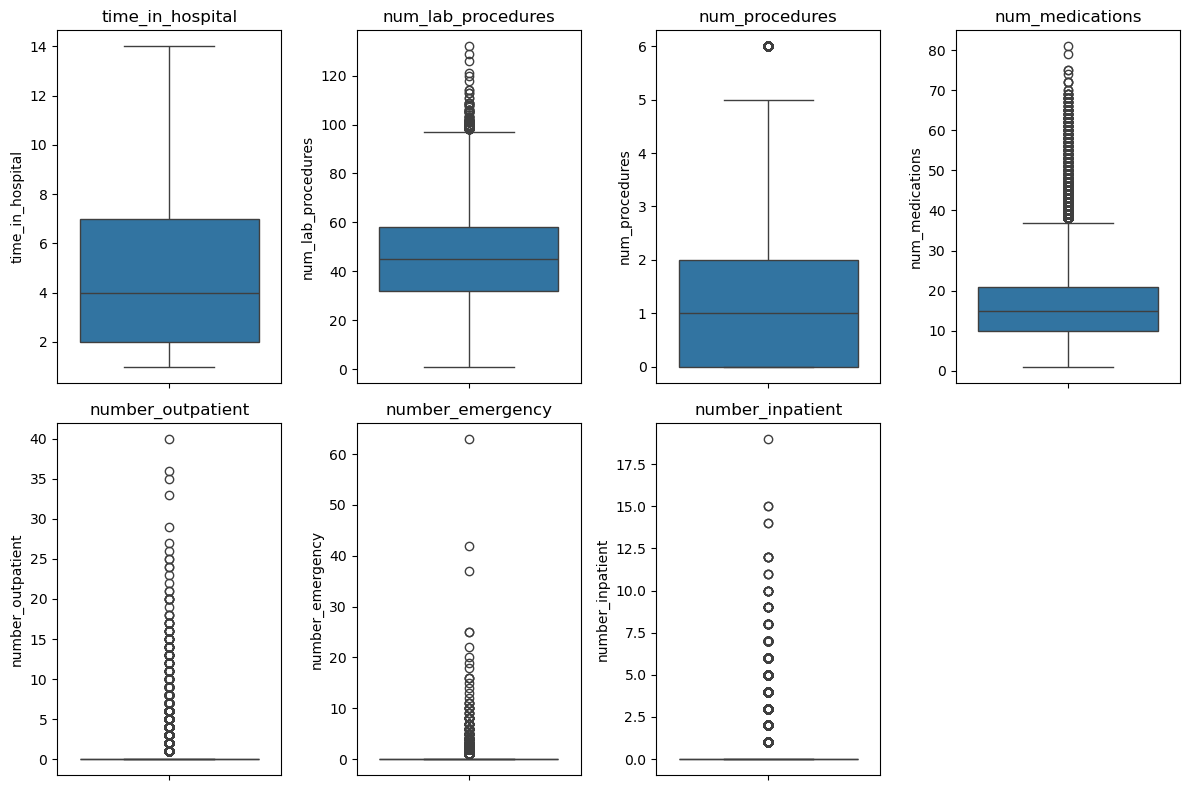

In [161]:
numerical_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
                 'number_outpatient', 'number_emergency', 'number_inpatient']

outliers_iqr = {}
for col in numerical_cols:
    Q1 = main_df[col].quantile(0.25)
    Q3 = main_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = main_df[(main_df[col] < lower_bound) | (main_df[col] > upper_bound)][col]
    outliers_iqr[col] = {'count': len(outliers), 'lower_bound': lower_bound, 'upper_bound': upper_bound}
print("\nIQR Outliers Summary:", outliers_iqr)

plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=main_df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [162]:
outliers_zscore = {}
for col in numerical_cols:
    z_scores = np.abs((main_df[col] - main_df[col].mean()) / main_df[col].std())
    outliers = main_df[z_scores > 3][col]
    outliers_zscore[col] = {'count': len(outliers), 'threshold': 3}
print("Z-score Outliers Summary:", outliers_zscore)

Z-score Outliers Summary: {'time_in_hospital': {'count': 0, 'threshold': 3}, 'num_lab_procedures': {'count': 32, 'threshold': 3}, 'num_procedures': {'count': 0, 'threshold': 3}, 'num_medications': {'count': 1018, 'threshold': 3}, 'number_outpatient': {'count': 1443, 'threshold': 3}, 'number_emergency': {'count': 558, 'threshold': 3}, 'number_inpatient': {'count': 1914, 'threshold': 3}}


In [166]:
main_df_iqr = main_df.copy()

for col in numerical_cols:
    Q1 = main_df_iqr[col].quantile(0.25)
    Q3 = main_df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    main_df_iqr[col] = main_df_iqr[col].clip(lower=lower_bound, upper=upper_bound)
print("IQR Capped Summary:\n", main_df_iqr[numerical_cols].describe())

IQR Capped Summary:
        time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count      71518.000000        71518.000000    71518.000000     71518.000000   
mean           4.759235           44.114852        1.431192        16.181227   
std            3.180147           19.952094        1.641980         7.892451   
min            1.000000            1.000000        0.000000         1.000000   
25%            2.000000           32.000000        0.000000        10.000000   
50%            4.000000           45.000000        1.000000        15.000000   
75%            7.000000           58.000000        2.000000        21.000000   
max           14.000000           97.000000        5.000000        37.500000   

       number_outpatient  number_emergency  number_inpatient  
count            71518.0           71518.0           71518.0  
mean                 0.0               0.0               0.0  
std                  0.0               0.0               0.0  
min   

In [168]:
main_df_zscore = main_df.copy()

for col in numerical_cols:
    mean = main_df_zscore[col].mean()
    std = main_df_zscore[col].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    main_df_zscore[col] = main_df_zscore[col].clip(lower=lower_bound, upper=upper_bound)
print("Z-score Clipped Summary:\n", main_df_zscore[numerical_cols].describe())

Z-score Clipped Summary:
        time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count      71518.000000        71518.000000    71518.000000     71518.000000   
mean           4.759235           44.120893        1.489345        16.273073   
std            3.180147           19.968937        1.779312         8.160490   
min            1.000000            1.000000        0.000000         1.000000   
25%            2.000000           32.000000        0.000000        10.000000   
50%            4.000000           45.000000        1.000000        15.000000   
75%            7.000000           58.000000        2.000000        21.000000   
max           14.000000          104.062877        6.000000        42.244241   

       number_outpatient  number_emergency  number_inpatient  
count       71518.000000      71518.000000      71518.000000  
mean            0.255324          0.103064          0.291524  
std             0.737303          0.368229          0.646363  
m

In [170]:
main_df= main_df_iqr

In [172]:
categorical_cols = ['race', 'gender', 'age', 'admission_type_desc', 
                   'discharge_disposition_desc', 'admission_source_desc', 
                   'diag_1_group', 'diag_2_group', 'diag_3_group', 'metformin',
                    'repaglinide','nateglinide', 'chlorpropamide','glimepiride',
                    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
                    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
                    'tolazamide', 'examide', 'citoglipton', 'insulin',
                    'glyburide-metformin', 'glipizide-metformin',
                    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                    'metformin-pioglitazone', 'change', 'diabetesMed']

# One-hot encoding
main_df_encoded = pd.get_dummies(main_df, columns=categorical_cols, drop_first=True)

main_df_encoded.drop(columns=['admission_type_id', 'discharge_disposition_id', 
                             'admission_source_id', 'diag_1', 'diag_2', 'diag_3', 
                             'readmitted'], inplace=True)

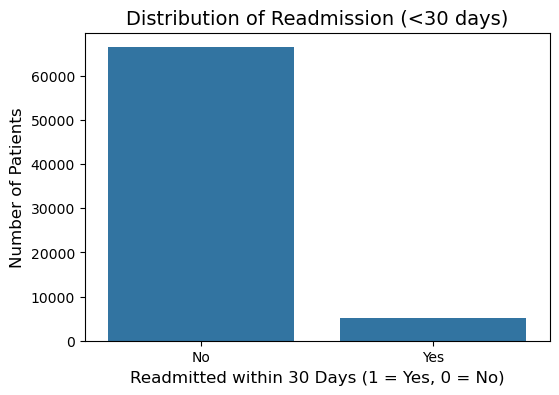

In [175]:
plt.figure(figsize=(6, 4))
sns.countplot(x='readmitted_binary', data=main_df)
plt.title('Distribution of Readmission (<30 days)', fontsize=14)
plt.xlabel('Readmitted within 30 Days (1 = Yes, 0 = No)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

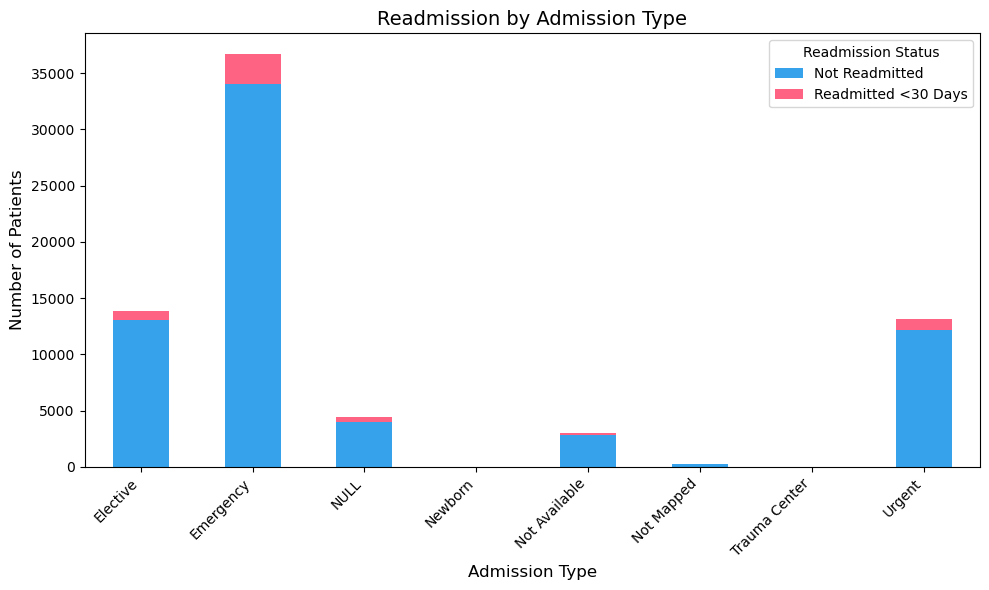

In [177]:
admission_readmission = main_df.groupby(['admission_type_desc', 'readmitted_binary']).size().unstack(fill_value=0)

admission_readmission.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#36A2EB', '#FF6384'])
plt.title('Readmission by Admission Type', fontsize=14)
plt.xlabel('Admission Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(['Not Readmitted', 'Readmitted <30 Days'], title='Readmission Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

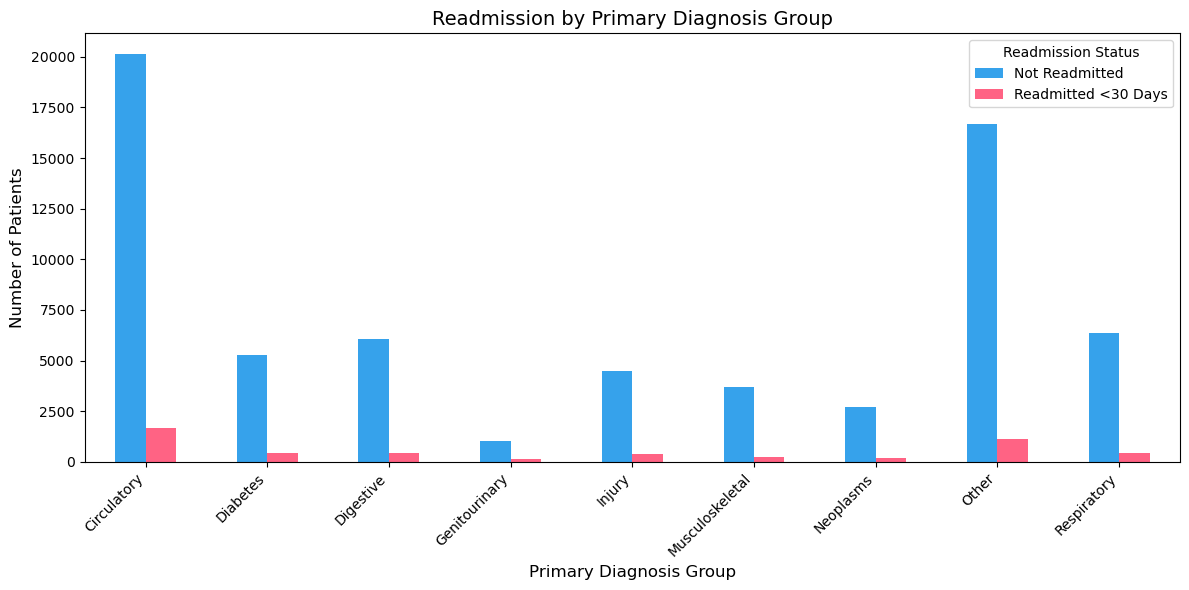

In [179]:
diag_readmission = main_df.groupby(['diag_1_group', 'readmitted_binary']).size().unstack(fill_value=0)

diag_readmission.plot(kind='bar', figsize=(12, 6), color=['#36A2EB', '#FF6384'])
plt.title('Readmission by Primary Diagnosis Group', fontsize=14)
plt.xlabel('Primary Diagnosis Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(['Not Readmitted', 'Readmitted <30 Days'], title='Readmission Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [182]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
main_df_encoded[numerical_cols] = scaler.fit_transform(main_df_encoded[numerical_cols])
print("Scaled Numerical Columns Summary:\n", main_df_encoded[numerical_cols].describe())


Scaled Numerical Columns Summary:
        time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count      7.151800e+04        7.151800e+04    7.151800e+04     7.151800e+04   
mean       2.543401e-17       -2.066513e-17    1.025308e-16     1.599561e-17   
std        1.000007e+00        1.000007e+00    1.000007e+00     1.000007e+00   
min       -1.182103e+00       -2.160934e+00   -8.716318e-01    -1.923526e+00   
25%       -8.676501e-01       -6.072013e-01   -8.716318e-01    -7.831877e-01   
50%       -2.387439e-01        4.436396e-02   -2.626068e-01    -1.496665e-01   
75%        7.046153e-01        6.959292e-01    3.464182e-01     6.105590e-01   
max        2.905787e+00        2.650625e+00    2.173493e+00     2.701179e+00   

       number_outpatient  number_emergency  number_inpatient  
count            71518.0           71518.0           71518.0  
mean                 0.0               0.0               0.0  
std                  0.0               0.0             

In [184]:
from sklearn.model_selection import train_test_split

X = main_df_encoded.drop(columns=['readmitted_binary'])
y = main_df_encoded['readmitted_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [187]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("SMOTE Synthetic Data Summary:\n", pd.DataFrame(X_train_res, columns=X.columns)[numerical_cols].describe())

SMOTE Synthetic Data Summary:
        time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
count     106194.000000       106194.000000   106194.000000    106194.000000   
mean           0.163244            0.102996        0.023331         0.111618   
std            1.019786            0.947450        0.992015         0.993399   
min           -1.182103           -2.160934       -0.871632        -1.923526   
25%           -0.553197           -0.446501       -0.871632        -0.623325   
50%           -0.034038            0.149868       -0.262607        -0.022962   
75%            0.707956            0.764378        0.651066         0.665607   
max            2.905787            2.650625        2.173493         2.701179   

       number_outpatient  number_emergency  number_inpatient  
count           106194.0          106194.0          106194.0  
mean                 0.0               0.0               0.0  
std                  0.0               0.0               0.

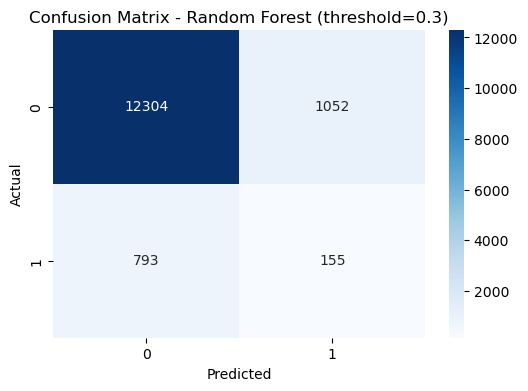

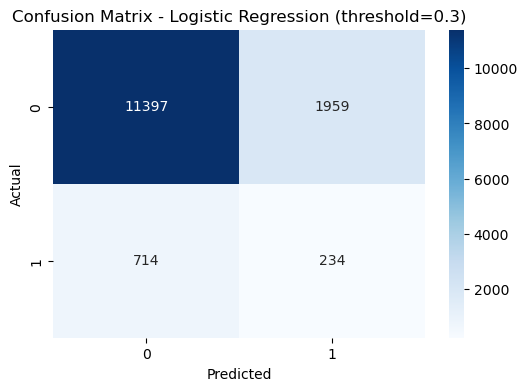

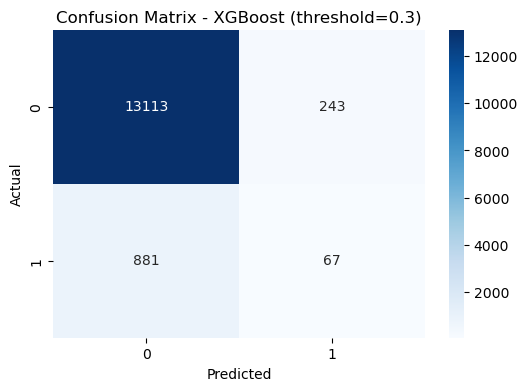

In [189]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, recall_score, precision_score, f1_score

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)   
}

results = []
threshold = 0.3 
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    
    y_proba = model.predict_proba(X_test)[:, 1]
    
    y_pred_thresh = (y_proba >= threshold).astype(int)
    
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_proba)
    accuracy = report['accuracy']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']
    precision = report['1']['precision']

    results.append({
        'Model': name,
        'Threshold': threshold,
        'Accuracy': accuracy,
        'Recall (Class 1)': recall,
        'Precision (Class 1)': precision,
        'F1-score (Class 1)': f1,
        'ROC-AUC': roc_auc
    })

    cm = confusion_matrix(y_test, y_pred_thresh)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name} (threshold={threshold})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    plt.close()


Model Comparison:
                  Model  Threshold  Accuracy  Recall (Class 1)  \
0        Random Forest        0.3  0.871015          0.163502   
1  Logistic Regression        0.3  0.813129          0.246835   
2              XGBoost        0.3  0.921421          0.070675   

   Precision (Class 1)  F1-score (Class 1)   ROC-AUC  
0             0.128418            0.143852  0.628736  
1             0.106703            0.148997  0.589721  
2             0.216129            0.106518  0.649410  


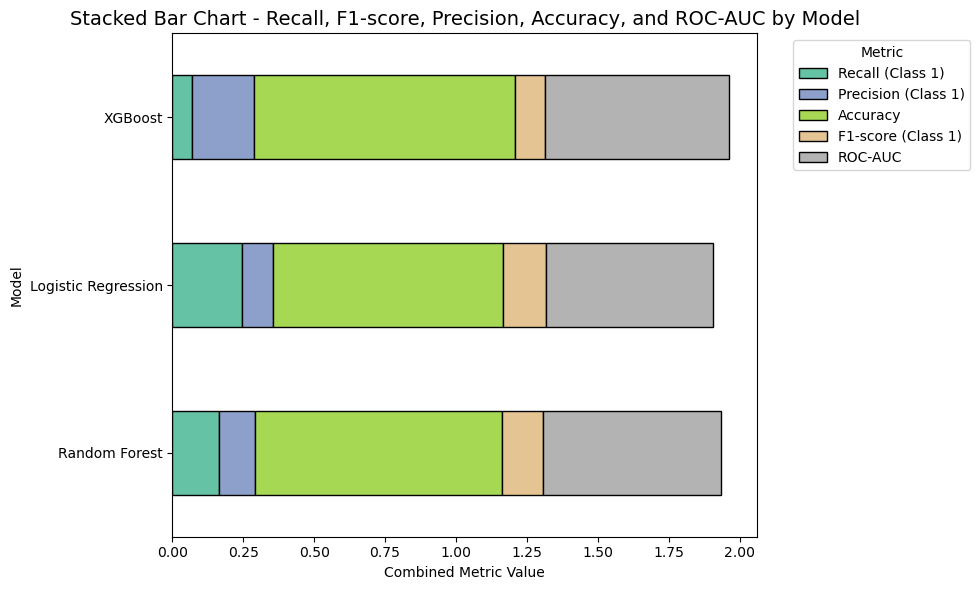

In [192]:
results_df = pd.DataFrame(results)
print("\nModel Comparison:\n", results_df)

plot_df = results_df.set_index('Model')[['Recall (Class 1)', 'Precision (Class 1)', 'Accuracy', 'F1-score (Class 1)', 'ROC-AUC']]

plot_df.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='Set2', edgecolor='black')

plt.title('Stacked Bar Chart - Recall, F1-score, Precision, Accuracy, and ROC-AUC by Model', fontsize=14)
plt.xlabel('Combined Metric Value')
plt.ylabel('Model')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.close()

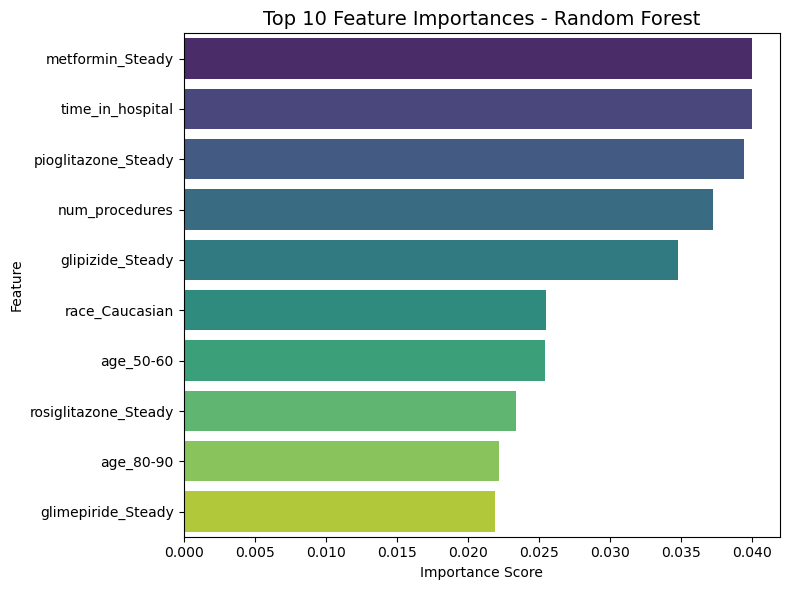

In [203]:
feature_importance = pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance.values,y=feature_importance.index,hue=feature_importance.index,palette='viridis',legend=False)
plt.title('Top 10 Feature Importances - Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()
plt.close()